In [1]:
# ── Gerekli Kütüphaneler ──────────────────────────────────────────────────────
# Unsloth'u ÖNCE kur, sonra diğerlerini
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes -q
!pip install datasets -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.7/842.7 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 26.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 62.9 MB/s

In [2]:
import torch
import json
import math
import random
import matplotlib.pyplot as plt
from datasets import load_dataset
from unsloth import FastLanguageModel   # ← Artık aktif kullanıyoruz
from trl import SFTConfig, SFTTrainer

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
#veri seti yükleme

full_dataset = load_dataset("json", data_files="analiz_sbertsiz.jsonl", split="train")
print(f"Toplam örnek sayısı: {len(full_dataset)}")

# Önce %10 test ayır
split_1 = full_dataset.train_test_split(test_size=0.10, seed=42)
train_val    = split_1["train"]
test_dataset = split_1["test"]

# Kalanın %11.1'i → toplam verinin %10'u validation olur
split_2       = train_val.train_test_split(test_size=0.111, seed=42)
train_dataset = split_2["train"]
val_dataset   = split_2["test"]

print(f"\nVeri dağılımı:")
print(f"  Train      : {len(train_dataset)} örnek ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  Validation : {len(val_dataset)} örnek ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"  Test       : {len(test_dataset)} örnek ({len(test_dataset)/len(full_dataset)*100:.1f}%)")

Generating train split: 0 examples [00:00, ? examples/s]

Toplam örnek sayısı: 1240

Veri dağılımı:
  Train      : 992 örnek (80.0%)
  Validation : 124 örnek (10.0%)
  Test       : 124 örnek (10.0%)


QWEN 3 İÇİN

In [5]:
# ── Ortak Parametreler ────────────────────────────────────────────────────────
MAX_SEQ_LENGTH = 2048   # Her iki model için aynı
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
MAX_STEPS      = 500

# LoRA hedef modüller (Qwen ve Llama için ortak isimler)
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

def get_training_args(output_dir):
    """Her iki model için aynı eğitim ayarları — adil karşılaştırma."""
    return SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        optim="adamw_8bit",             # Unsloth ile uyumlu optimizer
        learning_rate=2e-4,
        max_steps=MAX_STEPS,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        # ── Validation Ayarları ──────────────────
        eval_strategy="steps", # Changed evaluation_strategy to eval_strategy
        eval_steps=50,
        save_steps=100,
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        # ─────────────────────────────────────────
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LENGTH,
        push_to_hub=False,
        report_to="none"
    )

def plot_training_history(log_history, model_name):
    """Train ve Validation loss grafiğini çizer."""
    train_steps, train_losses = [], []
    eval_steps,  eval_losses  = [], []

    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(10, 5))
    plt.plot(train_steps, train_losses, label="Train Loss",      alpha=0.7)
    plt.plot(eval_steps,  eval_losses,  label="Validation Loss", marker="o")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Eğitim & Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{model_name.replace('/', '_')}_loss.png", dpi=150)
    plt.show()
    print(f"Son Train Loss : {train_losses[-1]:.4f}")
    print(f"Son Val Loss   : {eval_losses[-1]:.4f}")

print("Yardımcı fonksiyonlar hazır ✓")

Yardımcı fonksiyonlar hazır ✓


Modeli Yükleme

In [6]:
# ── Qwen3 Model Yükleme (Unsloth) ────────────────────────────────────────────
QWEN_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
# QWEN_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"  # Orijinal modelin varsa bunu kullan

print(f"Yükleniyor: {QWEN_MODEL_NAME}")

qwen_model, qwen_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = QWEN_MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,          # 4-bit quantization (BnbConfig'e gerek yok)
    dtype          = None,          # Otomatik tespit (bf16 destekliyorsa bf16)
)

# LoRA adaptörlerini ekle (prepare_model_for_kbit_training'e gerek yok)
qwen_model = FastLanguageModel.get_peft_model(
    qwen_model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGET_MODULES,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  # Unsloth'a özgü, %30 daha az VRAM
    random_state   = 42,
)

qwen_model.print_trainable_parameters()

Yükleniyor: Qwen/Qwen3-4B-Instruct-2507
==((====))==  Unsloth 2026.5.3: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-4b-instruct-2507-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.3 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


Veri Setini EOS ile Formatlama

In [7]:
# ── Alpaca Format Dönüşümü ────────────────────────────────────────────────────
def formatting_func(example):
    text = (
        f"### Instruction:\n{example['instruction']}\n\n"
        f"### Input:\n{example['input']}\n\n"
        f"### Response:\n{example['output']}{qwen_tokenizer.eos_token}"
    )
    return {"text": text}

train_dataset = train_dataset.map(formatting_func, remove_columns=train_dataset.column_names)
val_dataset   = val_dataset.map(formatting_func,   remove_columns=val_dataset.column_names)
test_dataset  = test_dataset.map(formatting_func,  remove_columns=test_dataset.column_names)

print("Format örneği:")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

Map:   0%|          | 0/124 [00:00<?, ? examples/s]

Format örneği:
### Instruction:
Öğrenci cevabını analiz et, 0.0-1.0 arasında bir puan ver.

### Input:
Soru: Kloroplastın granum ve stroma kısımlarında hangi olaylar gerçekleşir?
Doğru Cevap: Granumlarda ışığa bağımlı reaksiyonlar (ATP ve NADPH üretimi) gerçekleşir. Stromada ise ışıktan bağımsız reaksiyonlar (besin sentezi/Calvin döngüsü) gerçekleşir.
Öğrenci Cevabı: Stroma glikoz üretir, granum ise oksijenle ça


Eğitim

In [8]:
# ── Qwen3 Eğitim ─────────────────────────────────────────────────────────────
qwen_trainer = SFTTrainer(
    model         = qwen_model,
    tokenizer     = qwen_tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,    # ← Validation seti
    args          = get_training_args("./qwen3_finetuned_sbertsiz"),
)

# VRAM durumunu göster
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"GPU: {gpu_stats.name} | VRAM: {gpu_stats.total_memory / 1e9:.1f} GB")
print(f"Eğitim öncesi ayrılan VRAM: {start_gpu_memory} GB")
print("\nQwen3 eğitimi başlıyor...")

qwen_result = qwen_trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
print(f"\nQwen3 eğitimi tamamlandı ✓")
print(f"Süre         : {qwen_result.metrics['train_runtime']:.1f} sn")
print(f"Peak VRAM    : {used_memory} GB")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/992 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/124 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
GPU: Tesla T4 | VRAM: 15.6 GB
Eğitim öncesi ayrılan VRAM: 3.49 GB

Qwen3 eğitimi başlıyor...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 992 | Num Epochs = 5 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,0.732717,0.647240
100,0.524990,0.520983
150,0.396918,0.498565
200,0.386205,0.481313
250,0.355276,0.461855
300,0.279337,0.483126
350,0.271760,0.466558
400,0.168326,0.508570
450,0.168813,0.501653
500,0.163240,0.505201


Unsloth: Restored added_tokens_decoder metadata in ./qwen3_finetuned_sbertsiz/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./qwen3_finetuned_sbertsiz/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./qwen3_finetuned_sbertsiz/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./qwen3_finetuned_sbertsiz/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./qwen3_finetuned_sbertsiz/checkpoint-500/tokenizer_config.json.



Qwen3 eğitimi tamamlandı ✓
Süre         : 3076.3 sn
Peak VRAM    : 4.449 GB


Grafik

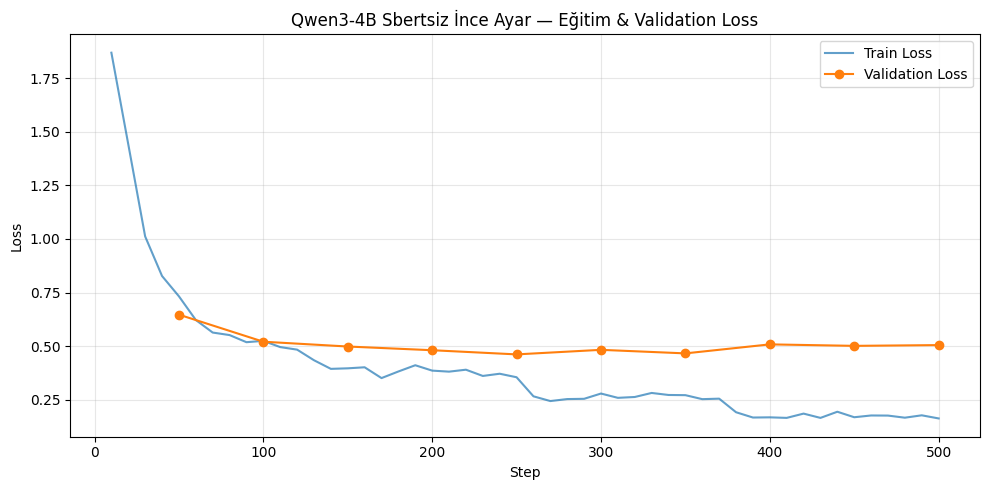

Son Train Loss : 0.1632
Son Val Loss   : 0.5052


In [9]:
# ── Qwen3 Sonuçları ───────────────────────────────────────────────────────────
plot_training_history(qwen_trainer.state.log_history, "Qwen3-4B Sbertsiz İnce Ayar")

Ağırlıkları Kaydetme Drive

In [10]:
# ── Qwen3 Kaydetme ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

QWEN_SAVE_DIR = "/content/drive/MyDrive/QWEN3_finetuned_eos_sbertsiz"
Path(QWEN_SAVE_DIR).mkdir(parents=True, exist_ok=True)

qwen_model.save_pretrained(QWEN_SAVE_DIR)   # LoRA ağırlıkları
qwen_tokenizer.save_pretrained(QWEN_SAVE_DIR)
print(f"Qwen3 kaydedildi: {QWEN_SAVE_DIR}")

# Validation metriklerini kaydet (karşılaştırma için)
qwen_metrics = {e["step"]: e["eval_loss"] for e in qwen_trainer.state.log_history if "eval_loss" in e}
with open("/content/drive/MyDrive/qwen3_val_metrics_sbertsiz.json", "w") as f:
    json.dump(qwen_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

Mounted at /content/drive


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/QWEN3_finetuned_eos_sbertsiz/tokenizer_config.json.


Qwen3 kaydedildi: /content/drive/MyDrive/QWEN3_finetuned_eos_sbertsiz
Validation metrikleri kaydedildi ✓


Ağırlıkları Kaydetme İndirme

In [ ]:
# ── Qwen3 Lokal İndirme ───────────────────────────────────────────────────────
import shutil
import json
from google.colab import files
from pathlib import Path

# 1. Modeli geçici klasöre kaydet
QWEN_SAVE_DIR = "/content/QWEN3_finetuned_eos_sbertsiz"
Path(QWEN_SAVE_DIR).mkdir(parents=True, exist_ok=True)

qwen_model.save_pretrained(QWEN_SAVE_DIR)
qwen_tokenizer.save_pretrained(QWEN_SAVE_DIR)
print(f"Qwen3 kaydedildi: {QWEN_SAVE_DIR}")

# 2. Validation metriklerini kaydet
qwen_metrics = {e["step"]: e["eval_loss"] for e in qwen_trainer.state.log_history if "eval_loss" in e}
metrics_path = "/content/qwen3_val_metrics_sbertsiz.json"
with open(metrics_path, "w") as f:
    json.dump(qwen_metrics, f, indent=2)
print("Validation metrikleri kaydedildi ✓")

# 3. Klasörü zip'le
zip_path = "/content/QWEN3_finetuned_eos_sbertsiz"
shutil.make_archive(zip_path, "zip", QWEN_SAVE_DIR)
print(f"Zip oluşturuldu: {zip_path}.zip")

# 4. İndir
files.download(f"{zip_path}.zip")
files.download(metrics_path)
print("İndirme başladı ✓")